# Choice decoding: selectivity subpop vs. full population

Compares `mode="choice"` decoding accuracy between two unit sets, per region and for the whole
population, overlaying true and shuffled accuracies for both:

| `sig_unit_level` | what it is |
|---|---|
| `choice_99th_window_filter_drift` | units passing the 99th-percentile choice-selectivity ANOVA |
| `all_filter_drift` | every unit, drift-filtered only |

Motivation: the selectivity subpop covers only 52% of the units in `pref_99th_window_filter_drift`,
so a choice axis fit on it has no weight for ~half the preference population. The full-population
runs exist so the choice axis can be restricted to preference units as a genuine sub-vector — see
`claude_notes/choice_axis_projection_dprime_design.md`. This notebook checks what that costs in
decoding accuracy.

Configs missing on disk are skipped and listed, so this runs both before and after
`slurm_launch_choice_all_units.sh` fills in the whole-population and ACC runs.

In [1]:
import os
import sys
import copy
import argparse

sys.path.append("/src/wcst_decode")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.pseudo_decoding.belief_partitions import belief_partitions_io as io
from constants.behavioral_constants import FEATURES
from constants.decoding_constants import REGIONS_OF_INTEREST
from utils.visualization_utils import REGION_TO_DISPLAY_NAME

In [2]:
BASE_PATH = "/data/patrick_res/choice_reward"
NUM_SHUFFLES = 10

# hue carries unit level, line style carries true/shuffle, so identity is never colour-alone.
# The two hues are validated for CVD separation: protan dE 24.7, normal-vision dE 33.6.
UNIT_LEVELS = {
    "choice_99th_window_filter_drift": ("choice-selective subpop", "#2a78d6"),
    "all_filter_drift":                ("full population",         "#eb6834"),
}
REGIONS = [None] + REGIONS_OF_INTEREST   # None == whole population
EVENTS = ["StimOnset", "FeedbackOnsetLong"]

GRID = "#9a9a92"


def make_args(level, region, event):
    """Namespace reproducing a choice_reward run's directory and file naming."""
    return argparse.Namespace(
        mode="choice",
        subject="both",
        trial_event=event,
        regions=region,
        region_level=None if region is None else "structure_level2_cleaned",
        beh_filters={},
        fr_type="firing_rates",
        sig_unit_level=level,
        splitter="random",
        num_splits=8,
        shuffle_idx=None,
        base_output_path=BASE_PATH,
    )


def region_label(region):
    return "all regions" if region is None else REGION_TO_DISPLAY_NAME[region]

## Load

In [3]:
accs, unit_counts, missing = [], [], []

for level in UNIT_LEVELS:
    for region in REGIONS:
        for event in EVENTS:
            args = make_args(level, region, event)
            run_dir = io.get_dir_name(args, make_dir=False)
            try:
                # read_results mutates args (shuffle_idx, feat, trial_interval), so hand it a copy
                res = io.read_results(copy.deepcopy(args), FEATURES, num_shuffles=NUM_SHUFFLES)
            except Exception as e:
                missing.append((UNIT_LEVELS[level][0], region_label(region), event, type(e).__name__))
                continue
            res["unit_level"] = level
            res["region"] = region_label(region)
            res["event"] = event
            accs.append(res)

            # population size actually handed to the decoder, per feature
            for feat in FEATURES:
                path = os.path.join(run_dir, f"{feat}_choice_unit_ids.csv")
                if os.path.exists(path):
                    unit_counts.append({
                        "unit_level": level, "region": region_label(region),
                        "event": event, "feat": feat, "n_units": len(pd.read_csv(path)),
                    })

accs = pd.concat(accs, ignore_index=True)
unit_counts = pd.DataFrame(unit_counts)

accs["kind"] = np.where(accs["mode"].str.contains("shuffle"), "shuffle", "true")
accs["level_label"] = accs["unit_level"].map(lambda l: UNIT_LEVELS[l][0])

print(f"loaded {len(accs):,} rows over {accs.region.nunique()} regions")
if missing:
    print(f"\nskipped {len(missing)} config(s) not on disk:")
    for lvl, reg, ev, err in missing:
        print(f"  {lvl:26s} {reg:32s} {ev:18s} ({err})")

loaded 658,896 rows over 7 regions

skipped 4 config(s) not on disk:
  full population            all regions                      StimOnset          (FileNotFoundError)
  full population            all regions                      FeedbackOnsetLong  (FileNotFoundError)
  full population            anterior cingulate cortex (ACC)  StimOnset          (FileNotFoundError)
  full population            anterior cingulate cortex (ACC)  FeedbackOnsetLong  (FileNotFoundError)


In [4]:
# median units per feature -- the main covariate behind any accuracy difference
units_wide = (
    unit_counts.groupby(["region", "event", "unit_level"], as_index=False)
    .n_units.median()
    .pivot_table(index=["region", "event"], columns="unit_level", values="n_units")
)
units_wide.columns = [UNIT_LEVELS[c][0] for c in units_wide.columns]
units_wide

full population  \
region                           event                                
all regions                      FeedbackOnsetLong              NaN   
                                 StimOnset                      NaN   
amygdala (AMY)                   FeedbackOnsetLong             42.5   
                                 StimOnset                     42.5   
anterior cingulate cortex (ACC)  FeedbackOnsetLong              NaN   
                                 StimOnset                      NaN   
dorsal striatum (DSTR)           FeedbackOnsetLong             36.5   
                                 StimOnset                     36.5   
hippocampal formation (HC)       FeedbackOnsetLong             52.5   
                                 StimOnset                     52.5   
inferior temporal cortex (ITC)   FeedbackOnsetLong             88.5   
                                 StimOnset                     88.5   
lateral prefrontal cortex (LPFC) FeedbackOnsetLong            102.0   
                                 StimOnset                    102.0   

                                                    choice-selective subpop  
region                           event                                       
all regions                      FeedbackOnsetLong                    257.0  
                                 StimOnset                            257.0  
amygdala (AMY)                   FeedbackOnsetLong                     19.0  
                                 StimOnset                             19.0  
anterior cingulate cortex (ACC)  FeedbackOnsetLong                     11.0  
                                 StimOnset                             11.0  
dorsal striatum (DSTR)           FeedbackOnsetLong                     12.5  
                                 StimOnset                             12.5  
hippocampal formation (HC)       FeedbackOnsetLong                     19.0  
                                 StimOnset                             19.0  
inferior temporal cortex (ITC)   FeedbackOnsetLong                     54.5  
                                 StimOnset                             54.5  
lateral prefrontal cortex (LPFC) FeedbackOnsetLong                     51.0  
                                 StimOnset                             51.0

## True vs shuffled accuracy, both unit sets

Colour = unit set, solid = true, dashed = shuffle. Bands are SE across features x runs
(x shuffle index for the shuffle traces). Grey line marks chance; dotted vertical marks event onset.
The `n=` annotation gives median units per feature for each unit set.

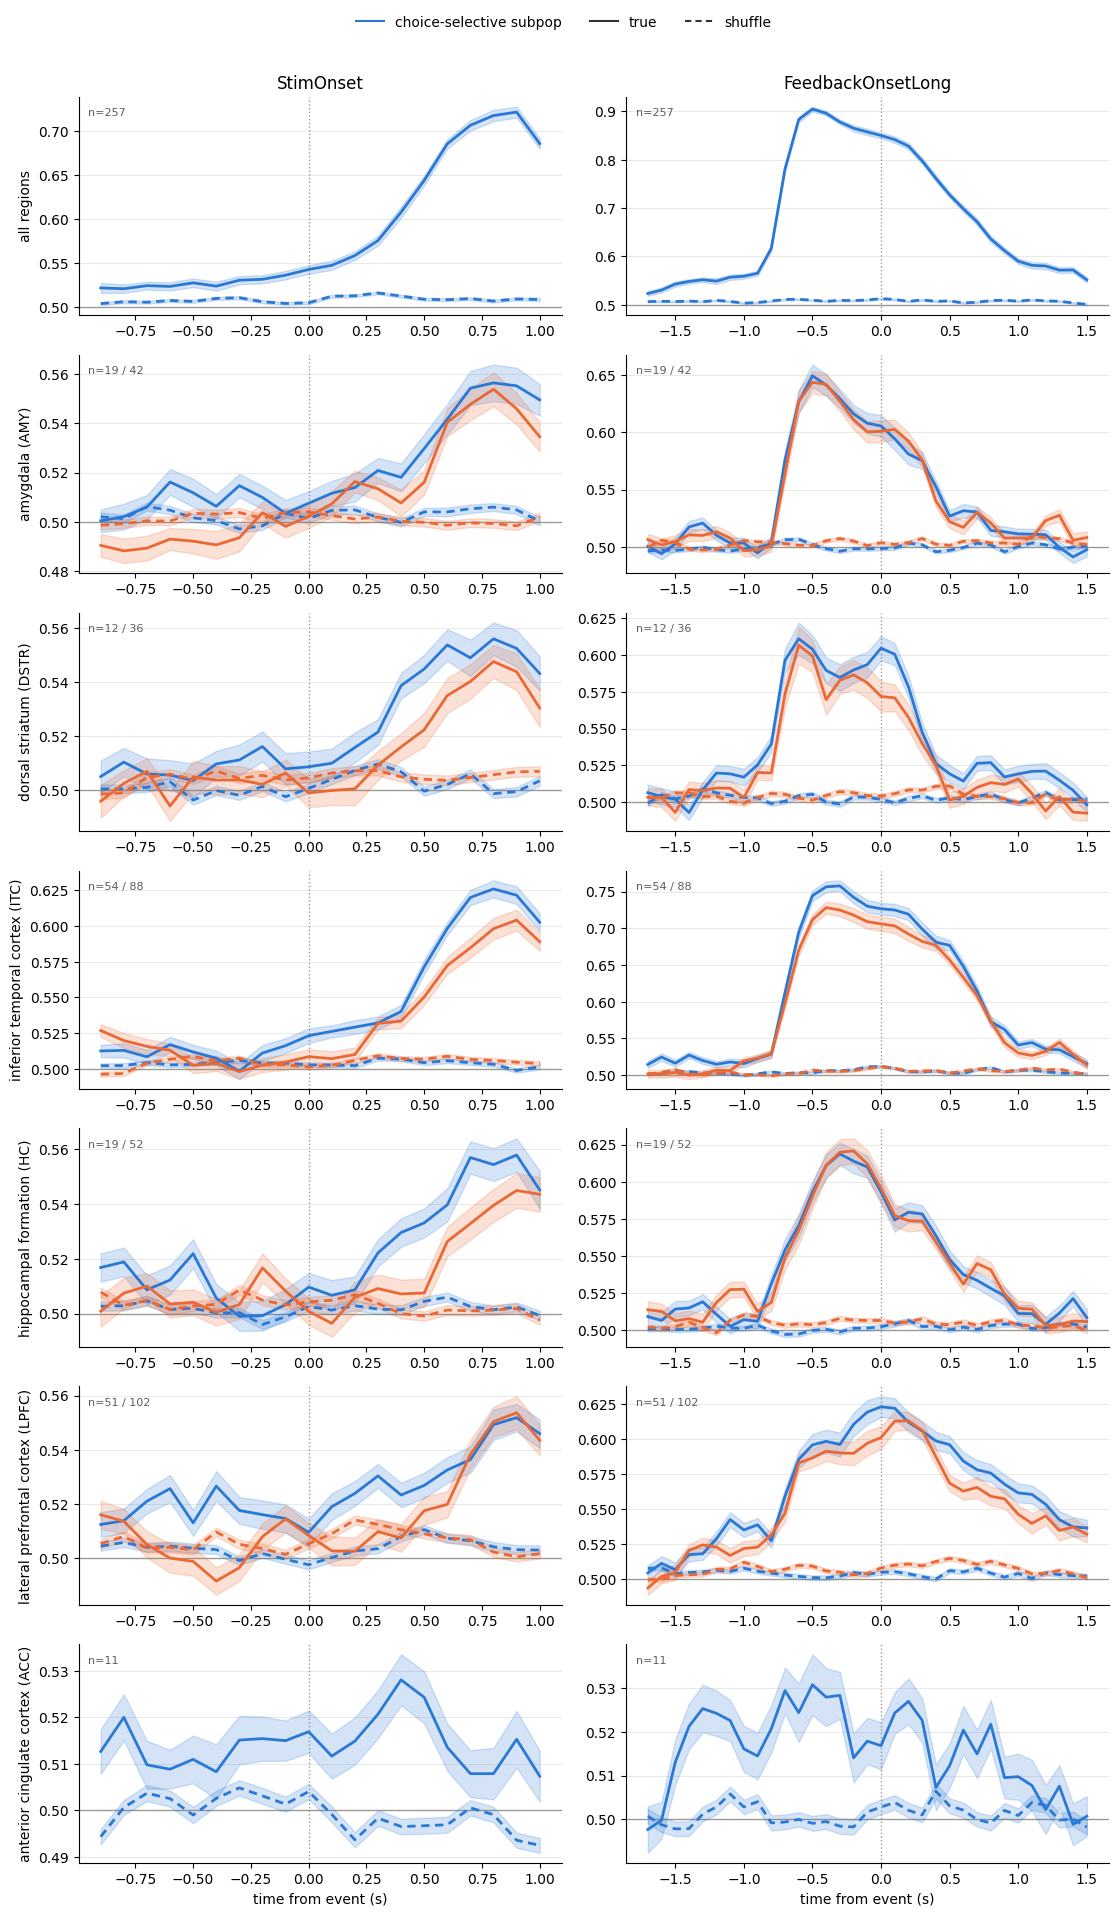

In [5]:
palette = {label: color for label, color in UNIT_LEVELS.values()}
dashes = {"true": "", "shuffle": (3, 2)}

present = [region_label(r) for r in REGIONS if region_label(r) in set(accs.region)]

fig, axes = plt.subplots(
    len(present), len(EVENTS),
    figsize=(5.6 * len(EVENTS), 2.7 * len(present)),
    squeeze=False,
)

for i, region in enumerate(present):
    for j, event in enumerate(EVENTS):
        ax = axes[i][j]
        sub = accs[(accs.region == region) & (accs.event == event)]
        if len(sub) == 0:
            ax.set_axis_off()
            continue

        sns.lineplot(
            data=sub, x="Time", y="Accuracy",
            hue="level_label", style="kind",
            palette=palette, dashes=dashes,
            errorbar="se", linewidth=2, ax=ax,
            legend=(i == 0 and j == 0),
        )
        ax.axhline(0.5, color=GRID, lw=1, zorder=0)
        ax.axvline(0, color=GRID, lw=1, ls=":", zorder=0)

        # annotate population sizes
        try:
            n_txt = " / ".join(
                f"{int(units_wide.loc[(region, event), lbl])}"
                for _, (lbl, _c) in UNIT_LEVELS.items()
                if lbl in units_wide.columns and not pd.isna(units_wide.loc[(region, event), lbl])
            )
            ax.text(0.02, 0.95, f"n={n_txt}", transform=ax.transAxes,
                    va="top", ha="left", fontsize=8, color="#5c5c55")
        except KeyError:
            pass

        ax.set_xlabel("time from event (s)" if i == len(present) - 1 else "")
        ax.set_ylabel(region if j == 0 else "")
        if i == 0:
            ax.set_title(event)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", color=GRID, alpha=0.25, lw=0.6)
        ax.set_axisbelow(True)

handles, labels = axes[0][0].get_legend_handles_labels()
axes[0][0].get_legend().remove()
# drop seaborn's group-title pseudo-entries so the legend reads as one flat row
keep = [(h, l) for h, l in zip(handles, labels) if l not in ("level_label", "kind")]
fig.legend([h for h, _ in keep], [l for _, l in keep],
           loc="upper center", bbox_to_anchor=(0.5, 1.015),
           ncol=len(keep), frameon=False)
fig.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

## Peak accuracy above shuffle

For each config, the time bin where (true - shuffle) is largest. `above_shuffle` is the fair
comparison: the `all_filter_drift` shuffle baseline sits differently because the decoder input
dimensionality differs.

In [6]:
mean_acc = (
    accs.groupby(["region", "event", "level_label", "kind", "Time"], as_index=False)
    .Accuracy.mean()
)
wide = (
    mean_acc.pivot_table(index=["region", "event", "level_label", "Time"],
                         columns="kind", values="Accuracy")
    .reset_index()
)
wide["above_shuffle"] = wide["true"] - wide["shuffle"]

summary = (
    wide.sort_values("above_shuffle", ascending=False)
    .groupby(["region", "event", "level_label"], as_index=False)
    .first()
    .sort_values(["event", "region", "level_label"])
    [["region", "event", "level_label", "Time", "true", "shuffle", "above_shuffle"]]
    .round(3)
    .reset_index(drop=True)
)
summary

kind,region,event,level_label,Time,true,shuffle,above_shuffle
0,all regions,FeedbackOnsetLong,choice-selective subpop,-0.5,0.905,0.509,0.395
1,amygdala (AMY),FeedbackOnsetLong,choice-selective subpop,-0.5,0.649,0.502,0.147
2,amygdala (AMY),FeedbackOnsetLong,full population,-0.5,0.644,0.501,0.143
3,anterior cingulate cortex (ACC),FeedbackOnsetLong,choice-selective subpop,-0.5,0.531,0.499,0.032
4,dorsal striatum (DSTR),FeedbackOnsetLong,choice-selective subpop,-0.6,0.611,0.504,0.107
5,dorsal striatum (DSTR),FeedbackOnsetLong,full population,-0.6,0.607,0.503,0.104
6,hippocampal formation (HC),FeedbackOnsetLong,choice-selective subpop,-0.3,0.619,0.499,0.120
7,hippocampal formation (HC),FeedbackOnsetLong,full population,-0.2,0.621,0.507,0.114
8,inferior temporal cortex (ITC),FeedbackOnsetLong,choice-selective subpop,-0.3,0.758,0.506,0.252
9,inferior temporal cortex (ITC),FeedbackOnsetLong,full population,-0.4,0.728,0.505,0.223


In [7]:
# side-by-side delta: does the full population buy anything over the selectivity subpop?
delta = (
    summary.pivot_table(index=["region", "event"], columns="level_label", values="above_shuffle")
)
cols = [lbl for lbl, _c in UNIT_LEVELS.values() if lbl in delta.columns]
if len(cols) == 2:
    delta["full - subpop"] = delta[cols[1]] - delta[cols[0]]
delta.round(3)

level_label                                         choice-selective subpop  \
region                           event                                        
all regions                      FeedbackOnsetLong                    0.395   
                                 StimOnset                            0.212   
amygdala (AMY)                   FeedbackOnsetLong                    0.147   
                                 StimOnset                            0.050   
anterior cingulate cortex (ACC)  FeedbackOnsetLong                    0.032   
                                 StimOnset                            0.032   
dorsal striatum (DSTR)           FeedbackOnsetLong                    0.107   
                                 StimOnset                            0.057   
hippocampal formation (HC)       FeedbackOnsetLong                    0.120   
                                 StimOnset                            0.055   
inferior temporal cortex (ITC)   FeedbackOnsetLong                    0.252   
                                 StimOnset                            0.123   
lateral prefrontal cortex (LPFC) FeedbackOnsetLong                    0.118   
                                 StimOnset                            0.049   

level_label                                         full population  \
region                           event                                
all regions                      FeedbackOnsetLong              NaN   
                                 StimOnset                      NaN   
amygdala (AMY)                   FeedbackOnsetLong            0.143   
                                 StimOnset                    0.054   
anterior cingulate cortex (ACC)  FeedbackOnsetLong              NaN   
                                 StimOnset                      NaN   
dorsal striatum (DSTR)           FeedbackOnsetLong            0.104   
                                 StimOnset                    0.042   
hippocampal formation (HC)       FeedbackOnsetLong            0.114   
                                 StimOnset                    0.046   
inferior temporal cortex (ITC)   FeedbackOnsetLong            0.223   
                                 StimOnset                    0.100   
lateral prefrontal cortex (LPFC) FeedbackOnsetLong            0.103   
                                 StimOnset                    0.053   

level_label                                         full - subpop  
region                           event                             
all regions                      FeedbackOnsetLong            NaN  
                                 StimOnset                    NaN  
amygdala (AMY)                   FeedbackOnsetLong         -0.004  
                                 StimOnset                  0.004  
anterior cingulate cortex (ACC)  FeedbackOnsetLong            NaN  
                                 StimOnset                    NaN  
dorsal striatum (DSTR)           FeedbackOnsetLong         -0.003  
                                 StimOnset                 -0.015  
hippocampal formation (HC)       FeedbackOnsetLong         -0.006  
                                 StimOnset                 -0.009  
inferior temporal cortex (ITC)   FeedbackOnsetLong         -0.029  
                                 StimOnset                 -0.023  
lateral prefrontal cortex (LPFC) FeedbackOnsetLong         -0.015  
                                 StimOnset                  0.004